In [14]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot

In [16]:
# load the dataset
df = pd.read_excel('BBDM Project for 2nd research article.xlsx')

In [18]:
# Display the first few rows to explore the dataset
df.head()

,Chainage,CRS,Torque,PRchd,Thrust,RMR,RMC,Lithology,Formation,Weathering,Rock Strength,PRnet
0,150.7,3.0,516.5,10.333333,4013.5,20,V,"SIST, MST",LS,MW to HW,Weak,31.0
1,152.1,3.0,516.5,10.333333,4013.5,20,V,"SIST, MST",LS,MW to HW,Weak,31.0
2,153.5,3.0,516.5,9.166667,4013.5,20,V,"SIST, MST",LS,MW to HW,Weak,27.5
3,154.9,3.0,516.5,9.166667,4013.5,20,V,"SIST, MST",LS,MW to HW,Weak,27.5
4,156.3,3.0,516.5,9.166667,4013.5,20,V,"SIST, MST",LS,MW to HW,Weak,27.5


## Step 1: General information about the dataset

In [20]:
# Step 1: General information about the dataset
# Data types, non-null counts
print("General Information:")
print(df.info())

General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Chainage       8614 non-null   float64
 1   CRS            8614 non-null   float64
 2   Torque         8614 non-null   float64
 3   PRchd          8614 non-null   float64
 4   Thrust         8614 non-null   float64
 5   RMR            8614 non-null   int64  
 6   RMC            8614 non-null   object 
 7   Lithology      8614 non-null   object 
 8   Formation      8614 non-null   object 
 9   Weathering     8614 non-null   object 
 10  Rock Strength  8614 non-null   object 
 11  PRnet          8614 non-null   float64
dtypes: float64(6), int64(1), object(5)
memory usage: 807.7+ KB
None


In [22]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Chainage         0
CRS              0
Torque           0
PRchd            0
Thrust           0
RMR              0
RMC              0
Lithology        0
Formation        0
Weathering       0
Rock Strength    0
PRnet            0
dtype: int64


In [24]:
# Unique values per column
print("\nUnique Values per Column:")
print(df.nunique())


Unique Values per Column:
Chainage         8614
CRS                58
Torque            374
PRchd             271
Thrust           2404
RMR                45
RMC                 3
Lithology          10
Formation           6
Weathering          5
Rock Strength       3
PRnet             712
dtype: int64


## Step 2: Descriptive statistics

In [26]:
df.describe().round(2)

,Chainage,CRS,Torque,PRchd,Thrust,RMR,PRnet
count,8614.00,8614.00,8614.00,8614.00,8614.00,8614.00,8614.00
mean,6179.80,7.50,321.14,9.13,5020.10,38.48,67.77
std,3481.51,0.92,58.95,2.11,1048.18,7.29,15.53
min,150.70,2.60,142.00,1.70,2059.00,14.00,13.00
25%,3165.25,7.00,276.00,7.60,4265.50,35.00,56.00
50%,6179.80,8.00,320.00,9.00,5000.00,38.00,66.00
75%,9194.35,8.00,360.00,10.50,5783.00,42.00,79.10
max,12208.90,9.50,546.00,17.10,11800.00,60.00,128.50


## Step 3: Pearson Correlation Analysis

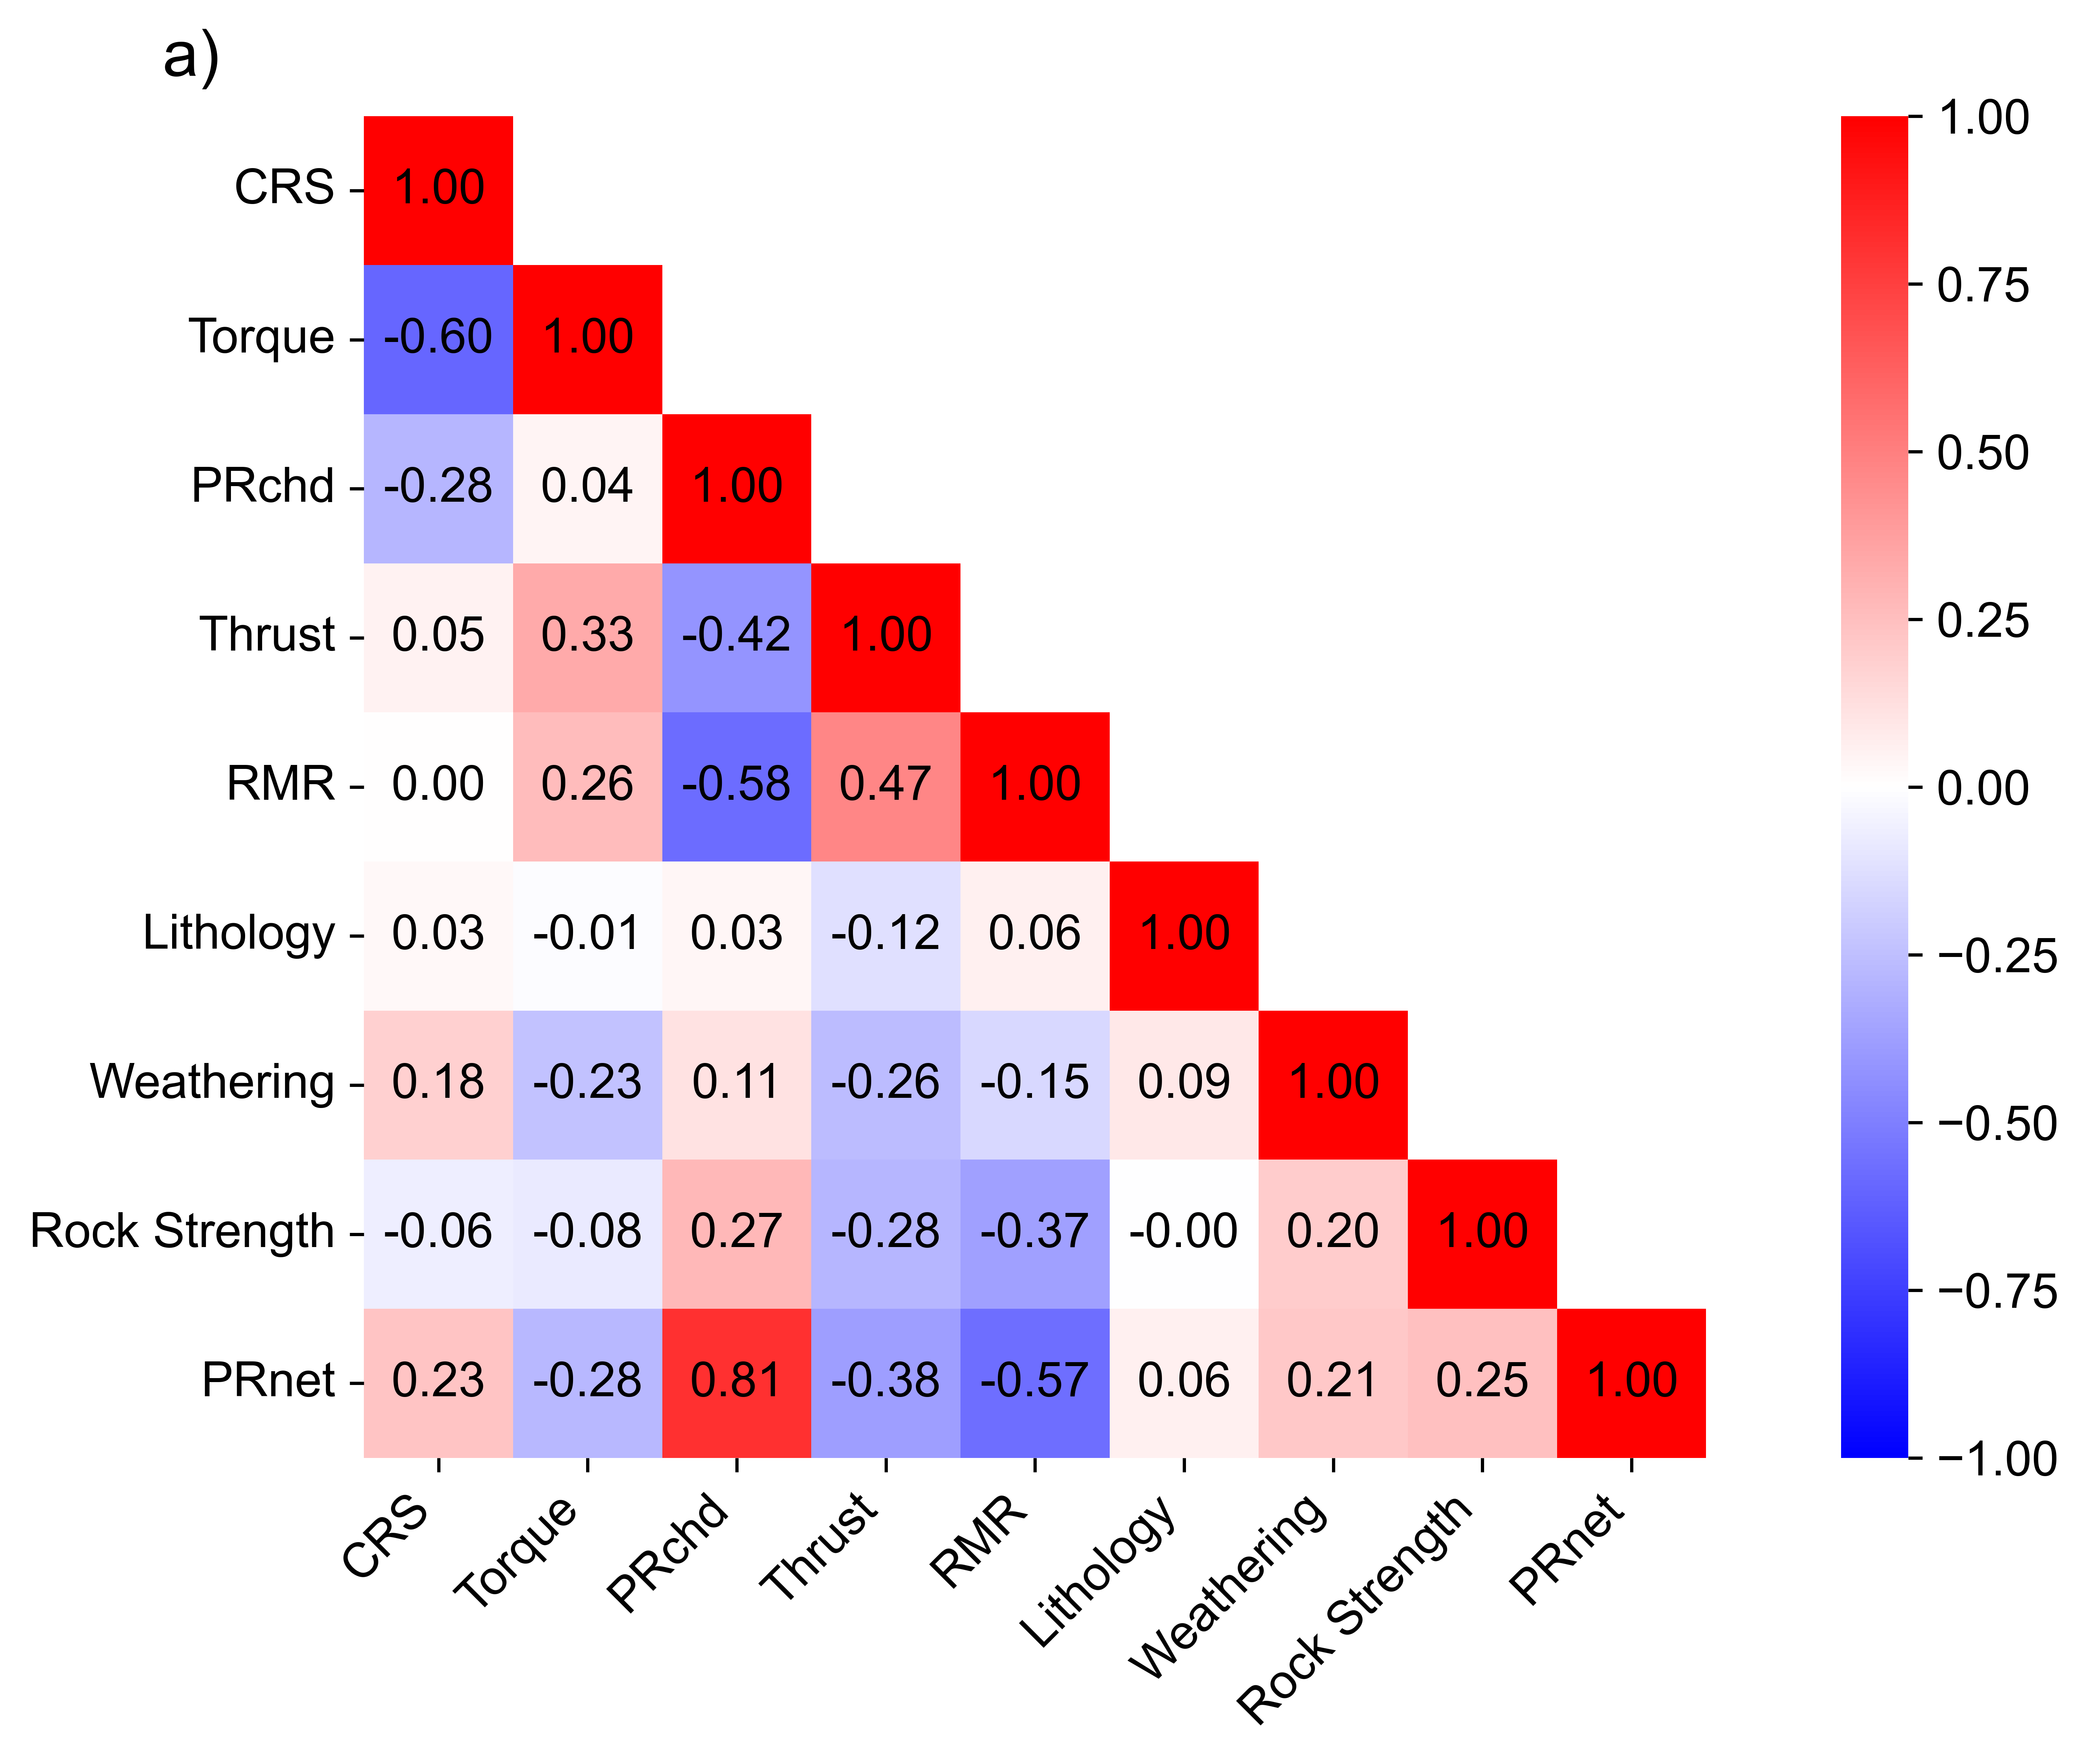

In [32]:
# Importing the Libraries
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import LabelEncoder

# Drop the columns you want to exclude
columns_to_exclude = ['Chainage', 'RMC',  'Formation']
heat_filtered = df.drop(columns=columns_to_exclude)

# Encode the categorical columns using label encoding
label_encoder = LabelEncoder()
for column in ['Lithology','Weathering', 'Rock Strength']:
    heat_filtered[column] = label_encoder.fit_transform(heat_filtered[column])

# Triangle Correlation Heatmap
plt.figure(figsize=(12, 6), dpi=800)
pyplot.rc('font', family='Arial')

# Compute the correlation matrix
corr_matrix = heat_filtered.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
np.fill_diagonal(mask, False)

# Custom annotation function
def annotate_heatmap(data, mask, fmt=".2f", **textkw):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not mask[i, j]:
                plt.text(j + 0.5, i + 0.5, format(data[i, j], fmt), 
                         ha="center", va="center", **textkw)

# Create a custom diverging colormap: blue -> white -> red
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    [(0.0, 'blue'), (0.5, 'white'), (1.0, 'red')]
)

# Plot the heatmap using the custom colormap
heatmap = sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1,
                      annot=False, cmap=custom_cmap, square=True)

# Manually annotate the heatmap
annotate_heatmap(corr_matrix.values, mask, fmt='.2f', fontsize=12, color='black')

# Set title with bold text
plt.text(
    x=-0.15,
    y=1.03,
    s="a)",
    fontsize=16,
    transform=plt.gca().transAxes
)

# Customize axis labels
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha="right", size=12, color='black')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=360, size=12, color='black')

# Customize ticks
plt.tick_params(axis='x', which='both', bottom=True, color='black')
plt.tick_params(axis='y', which='both', left=True, color='black')

# Customize colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelsize=12, colors='black')

# Save the figure
plt.savefig("a) correlation matrix for 'BBDM Project data.png", bbox_inches='tight', dpi=800)

# Show the plot
plt.show()

## Step 4: Features importance of input parameters

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Step 2: Drop specific columns
df = df.drop(columns=['Chainage','RMC','Formation' ])

# Label Encoding for ordinal categorical variables
label_encoder = LabelEncoder()
df['Rock Strength'] = label_encoder.fit_transform(df['Rock Strength'])
df['Weathering'] = label_encoder.fit_transform(df['Weathering'])
df['Lithology'] = label_encoder.fit_transform(df['Lithology'])


# Prepare Features and Target
X = df.drop(columns=['PRnet'])  # Input features
y = df['PRnet']                 # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Extract and visualize feature importance
feature_importances = rf_model.feature_importances_

# Convert feature importances to percentages
feature_importances_percentage = feature_importances * 100

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': feature_importances_percentage
}).sort_values(by='Importance (%)', ascending=False)

# Print the feature importance DataFrame
print(importance_df)

# Visualization of feature importance as a vertical bar chart
plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(10, 9), dpi=800)
bars = plt.bar(importance_df['Feature'], importance_df['Importance (%)'], color='lightgreen')
plt.ylabel('Importance (%)', color='black', fontsize=22)
plt.xlabel('Features', fontsize=22, color='black')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=22, color='black')

# Customize y-axis tick labels
plt.tick_params(axis='y', labelsize=22, labelcolor='black', length=5, width=2)
plt.tick_params(axis='x', labelsize=22, labelcolor='black', length=5, width=2)
# Add value annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}%',
             va='bottom', ha='center',rotation = 0,fontsize=22, color='black')

# Adjust layout to prevent clipping of tick labels
plt.title('b)', x=-0.1,y=1, fontsize=22)
plt.tight_layout()
# Save the figure
plt.savefig('Feature_importance_2nd_Journal.png', bbox_inches='tight', dpi=800)
# Display the plot
plt.show()

         Feature  Importance (%)
2          PRchd       70.894294
0            CRS       20.747933
4            RMR        3.169197
3         Thrust        2.129376
1         Torque        1.946432
5      Lithology        0.517344
6     Weathering        0.369331
7  Rock Strength        0.226093


## Step 5: Visualisation with Box–Whisker and Violin Plot

In [38]:
# If you are working with a subset of the original DataFrame, ensure you use .copy()
df = df.copy()
# Drop the columns you want to exclude
columns_to_exclude = ['Lithology', 'Weathering', 'Rock Strength']
df_filtered = df.drop(columns=columns_to_exclude)

In [40]:
df_filtered.head()

,CRS,Torque,PRchd,Thrust,RMR,PRnet
0,3.0,516.5,10.333333,4013.5,20,31.0
1,3.0,516.5,10.333333,4013.5,20,31.0
2,3.0,516.5,9.166667,4013.5,20,27.5
3,3.0,516.5,9.166667,4013.5,20,27.5
4,3.0,516.5,9.166667,4013.5,20,27.5


In [42]:
# Define the column names, units, and colors
columns = ["PRchd","CRS","RMR",  "Thrust", "Torque", "PRnet"]
colors = ["teal","blue",  "skyblue", "orange", "magenta", "green"]
units = ["[mm/rev]", "[rpm]", "[RMR]", "[kN]", "[kNm]", "[mm/min]"]

# Set font
plt.rcParams['font.family'] = 'Arial'

# Set up subplots as a 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), dpi=800)

# Flatten the 2D array of axes to make it easier to iterate through
axes = axes.flatten()

# Iterate through columns, units, and colors to create violin plots with box plots
for i, (column_name, unit, color) in enumerate(zip(columns, units, colors)):
    if i < len(axes):
        # Create a violin plot
        sns.violinplot(data=df_filtered[column_name], color=color, inner="quartiles", 
                       showfliers=False, showextrema=False, quantiles=[0.25, 0.5, 0.75], ax=axes[i])
        
        # Create a separate box plot on a second y-axis
        ax2 = axes[i].twinx()
        sns.boxplot(data=df_filtered[column_name], color="black", width=0.2, ax=ax2, 
                    boxprops=dict(facecolor='none', edgecolor='black'), medianprops=dict(color='red'))
        
        ax2.set_yticks([])  # Hide y-axis ticks for the box plot

        # Hide x-axis ticks and labels
        axes[i].set_xticks([])  # Remove x-axis ticks
        axes[i].set_xticklabels([])

        # Improved y-axis label: "ColumnName [Unit]"
        axes[i].set_ylabel(f"{column_name} {unit}", fontsize=18)

        # Adjust y-axis tick label size
        axes[i].tick_params(axis='y', labelsize=18)

# Adjust layout and show the plots
plt.tight_layout()

# Save the figure
plt.savefig('Box and Violonplot_2nd_Journal.png', bbox_inches='tight', dpi=800)
plt.show()

## Step 6: Distribution with histograms

In [46]:
# Define the column names, units, and colors
columns = ["PRchd","CRS","RMR", "Thrust", "Torque", "PRnet"]
colors = ["teal","blue", "skyblue", "orange", "magenta", "green"]
units = ["PRchd [mm/rev]","CRS [rpm]", "RMR [RMR]", "Thrust [kN]", "Torque [kNm]","PRnet [mm/min]"]

# Set font
plt.rcParams['font.family'] = 'Arial'

# Set the style for Seaborn
sns.set(style="white")

# Create subplots for each column
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), dpi=800)

# Flatten the 2D array of subplots for easier indexing
axes = axes.flatten()

# Plot histograms
for i, column in enumerate(columns):
    sns.histplot(df[column], kde=True, color=colors[i], ax=axes[i], 
                 bins=20, line_kws={'color': 'red'})  # Change KDE line color to red
    axes[i].set_xlabel(units[i], fontsize=20, color='black')
    axes[i].set_ylabel('Frequency', fontsize=20, color='black')
    axes[i].tick_params(axis='both', which='major', labelsize=20, labelcolor='black')

# Adjust layout
plt.tight_layout()
# Save the figure
plt.savefig('Data distribution_2nd_Journal.png', bbox_inches='tight', dpi=800)
plt.show()

C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Programs\Anaconda3\2024.02\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 